In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Воспроизводимость
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# ------------------- Генераторы масок -------------------
def circular_mask(size):
    center = size // 2
    radius = size // 2
    Y, X = np.ogrid[:size, :size]
    dist = np.sqrt((X - center)**2 + (Y - center)**2)
    return (dist <= radius).astype(np.float32)

def cross_mask(size):
    mask = np.zeros((size, size), dtype=np.float32)
    if size % 2 == 1:
        c = size // 2
        mask[c, :] = 1
        mask[:, c] = 1
    else:
        c1 = size // 2 - 1
        c2 = size // 2
        mask[c1, :] = 1
        mask[c2, :] = 1
        mask[:, c1] = 1
        mask[:, c2] = 1
    return mask

def checkerboard_mask(size):
    mask = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            if (i + j) % 2 == 0:
                mask[i, j] = 1
    return mask

def full_mask(size):
    return np.ones((size, size), dtype=np.float32)

In [3]:
# ------------------- Кастомный слой с маской -------------------
class MaskedConv2D(layers.Layer):
    def __init__(self, filters, kernel_size, mask,
                 strides=(1,1), padding='same', use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.strides = strides
        self.padding = padding
        self.use_bias = use_bias
        self.mask = tf.constant(mask, dtype=tf.float32)
        self.mask = tf.reshape(self.mask, (self.mask.shape[0], self.mask.shape[1], 1, 1))

    def build(self, input_shape):
        in_channels = input_shape[-1]
        kernel_shape = self.kernel_size + (in_channels, self.filters)
        self.kernel = self.add_weight(name='kernel', shape=kernel_shape,
                                      initializer='glorot_uniform', trainable=True)
        if self.use_bias:
            self.bias = self.add_weight(name='bias', shape=(self.filters,),
                                        initializer='zeros', trainable=True)
        else:
            self.bias = None
        self.mask = tf.tile(self.mask, [1, 1, in_channels, self.filters])

    def call(self, inputs):
        masked_kernel = self.kernel * self.mask
        outputs = tf.nn.conv2d(inputs, masked_kernel,
                               strides=[1, self.strides[0], self.strides[1], 1],
                               padding=self.padding.upper())
        if self.use_bias:
            outputs = tf.nn.bias_add(outputs, self.bias)
        return outputs


In [4]:
def build_model(input_shape=(64,64,3), num_classes=38, mask=None, kernel_size=3):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Первый блок
    model.add(MaskedConv2D(32, kernel_size, mask, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.3))

    # Второй блок – увеличиваем число фильтров
    model.add(MaskedConv2D(64, kernel_size, mask, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.3))

    # Головка
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

Found 49197 images belonging to 39 classes.
Found 12289 images belonging to 39 classes.
Количество классов: 39
Классы: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Background_without_leaves': 4, 'Blueberry___healthy': 5, 'Cherry___Powdery_mildew': 6, 'Cherry___healthy': 7, 'Corn___Cercospora_leaf_spot Gray_leaf_spot': 8, 'Corn___Common_rust': 9, 'Corn___Northern_Leaf_Blight': 10, 'Corn___healthy': 11, 'Grape___Black_rot': 12, 'Grape___Esca_(Black_Measles)': 13, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 14, 'Grape___healthy': 15, 'Orange___Haunglongbing_(Citrus_greening)': 16, 'Peach___Bacterial_spot': 17, 'Peach___healthy': 18, 'Pepper,_bell___Bacterial_spot': 19, 'Pepper,_bell___healthy': 20, 'Potato___Early_blight': 21, 'Potato___Late_blight': 22, 'Potato___healthy': 23, 'Raspberry___healthy': 24, 'Soybean___healthy': 25, 'Squash___Powdery_mildew': 26, 'Strawberry___Leaf_scorch': 27, 'Strawberry___healthy': 28, 'Tomato___

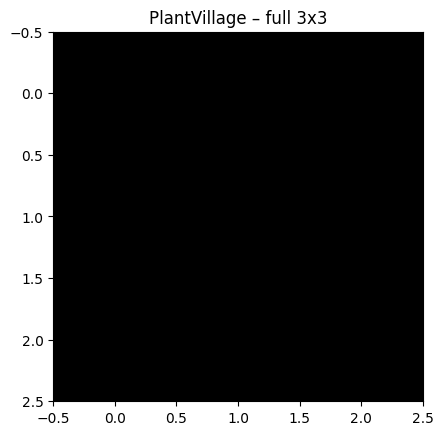

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 178s 461ms/step - accuracy: 0.4948 - loss: 2.4073 - val_accuracy: 0.0513 - val_loss: 10.6618
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 175s 454ms/step - accuracy: 0.6840 - loss: 1.1142 - val_accuracy: 0.7060 - val_loss: 0.9934
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 173s 450ms/step - accuracy: 0.7496 - loss: 0.8273 - val_accuracy: 0.6309 - val_loss: 1.2599
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 173s 450ms/step - accuracy: 0.7892 - loss: 0.6868 - val_accuracy: 0.6397 - val_loss: 1.4021
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 173s 450ms/step - accuracy: 0.8137 - loss: 0.5987 - val_accuracy: 0.7050 - val_loss: 1.0275
Test accuracy: 0.7069

=== Эксперимент: full, размер 5x5 ===


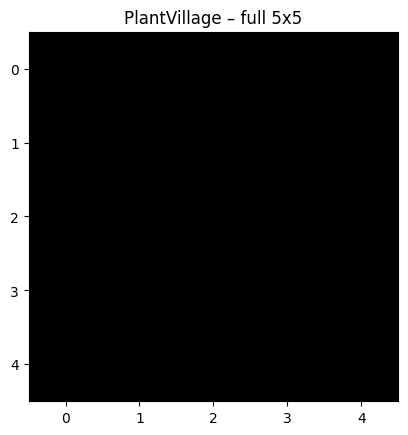

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 194s 502ms/step - accuracy: 0.4731 - loss: 2.4181 - val_accuracy: 0.1956 - val_loss: 5.3600
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 191s 497ms/step - accuracy: 0.6812 - loss: 1.1157 - val_accuracy: 0.6434 - val_loss: 1.2116
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 191s 496ms/step - accuracy: 0.7443 - loss: 0.8485 - val_accuracy: 0.6188 - val_loss: 1.4301
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 194s 503ms/step - accuracy: 0.7798 - loss: 0.7146 - val_accuracy: 0.7643 - val_loss: 0.7619
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 190s 495ms/step - accuracy: 0.8058 - loss: 0.6279 - val_accuracy: 0.6469 - val_loss: 1.2177
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 190s 493ms/step - accuracy: 0.8231 - loss: 0.5712 - val_accuracy: 0.7093 - val_loss: 0.9199
Epoch 7/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 195s 505ms/step - accuracy: 0.8410 - loss: 0.5172 - val_accuracy: 0.5911 - val_loss: 1.4793
Test accuracy: 0.7641

=== Эксперимент: circle, размер 5x5 ===


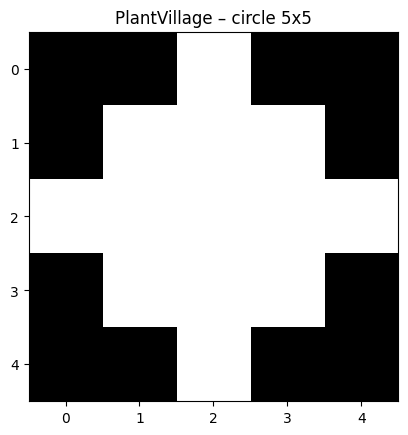

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 201s 518ms/step - accuracy: 0.4819 - loss: 2.3665 - val_accuracy: 0.0927 - val_loss: 8.2074
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 193s 501ms/step - accuracy: 0.6832 - loss: 1.0955 - val_accuracy: 0.4971 - val_loss: 1.8211
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 195s 507ms/step - accuracy: 0.7450 - loss: 0.8458 - val_accuracy: 0.6053 - val_loss: 1.3088
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 195s 507ms/step - accuracy: 0.7807 - loss: 0.7101 - val_accuracy: 0.7344 - val_loss: 0.8716
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 189s 491ms/step - accuracy: 0.8041 - loss: 0.6348 - val_accuracy: 0.7179 - val_loss: 0.9080
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 189s 492ms/step - accuracy: 0.8198 - loss: 0.5778 - val_accuracy: 0.7014 - val_loss: 0.9756
Epoch 7/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 183s 476ms/step - accuracy: 0.8399 - loss: 0.5151 - val_accuracy: 0.5619 - val_loss: 1.7005
Test accuracy: 0.7329

=== Эксперимент: circle, размер 6x6 ===


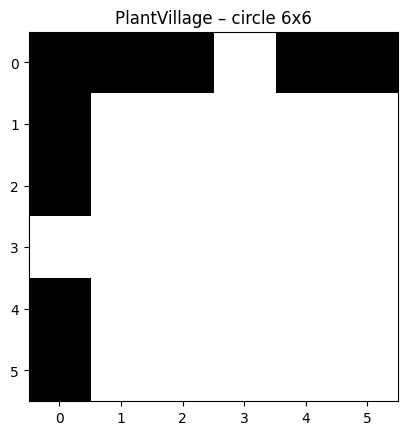

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 198s 512ms/step - accuracy: 0.4821 - loss: 2.4011 - val_accuracy: 0.1584 - val_loss: 6.6687
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 200s 519ms/step - accuracy: 0.6846 - loss: 1.1084 - val_accuracy: 0.6640 - val_loss: 1.1297
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 197s 513ms/step - accuracy: 0.7430 - loss: 0.8484 - val_accuracy: 0.7145 - val_loss: 0.9887
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 198s 515ms/step - accuracy: 0.7851 - loss: 0.6985 - val_accuracy: 0.7144 - val_loss: 0.9201
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 198s 514ms/step - accuracy: 0.8077 - loss: 0.6231 - val_accuracy: 0.7202 - val_loss: 0.9714
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 198s 515ms/step - accuracy: 0.8235 - loss: 0.5690 - val_accuracy: 0.7029 - val_loss: 1.0159
Epoch 7/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 198s 514ms/step - accuracy: 0.8373 - loss: 0.5215 - val_accuracy: 0.7897 - val_loss: 0.6809
Epoch 8/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 205s 534ms/step - accuracy: 0.8475 -

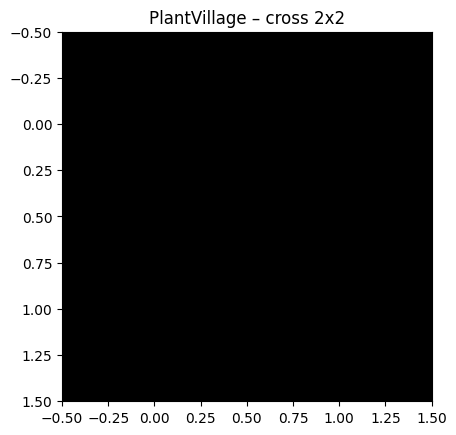

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 161s 416ms/step - accuracy: 0.4858 - loss: 2.6211 - val_accuracy: 0.0685 - val_loss: 9.5000
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 160s 415ms/step - accuracy: 0.6660 - loss: 1.2119 - val_accuracy: 0.6515 - val_loss: 1.1716
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 161s 419ms/step - accuracy: 0.7336 - loss: 0.8901 - val_accuracy: 0.7744 - val_loss: 0.7680
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 160s 416ms/step - accuracy: 0.7747 - loss: 0.7310 - val_accuracy: 0.7148 - val_loss: 0.9400
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 157s 407ms/step - accuracy: 0.8055 - loss: 0.6305 - val_accuracy: 0.6656 - val_loss: 1.1049
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 158s 411ms/step - accuracy: 0.8291 - loss: 0.5547 - val_accuracy: 0.3047 - val_loss: 3.9343
Test accuracy: 0.7727

=== Эксперимент: cross, размер 3x3 ===


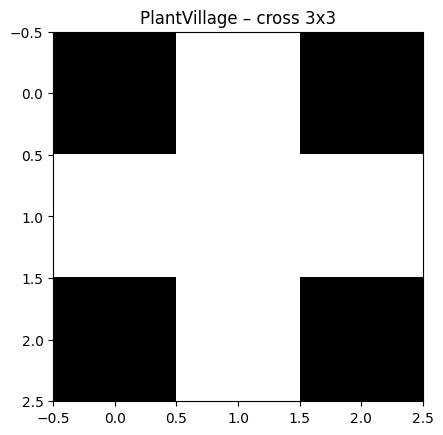

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 169s 435ms/step - accuracy: 0.4928 - loss: 2.5119 - val_accuracy: 0.0434 - val_loss: 9.5407
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 162s 422ms/step - accuracy: 0.6744 - loss: 1.1576 - val_accuracy: 0.7155 - val_loss: 0.9573
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 164s 426ms/step - accuracy: 0.7433 - loss: 0.8604 - val_accuracy: 0.7040 - val_loss: 0.9853
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 167s 433ms/step - accuracy: 0.7799 - loss: 0.7232 - val_accuracy: 0.7056 - val_loss: 0.9471
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 164s 427ms/step - accuracy: 0.8011 - loss: 0.6448 - val_accuracy: 0.5810 - val_loss: 1.6719
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 162s 421ms/step - accuracy: 0.8196 - loss: 0.5786 - val_accuracy: 0.7088 - val_loss: 0.9684
Epoch 7/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 153s 397ms/step - accuracy: 0.8408 - loss: 0.5148 - val_accuracy: 0.7696 - val_loss: 0.7718
Epoch 8/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 153s 398ms/step - accuracy: 0.8516 -

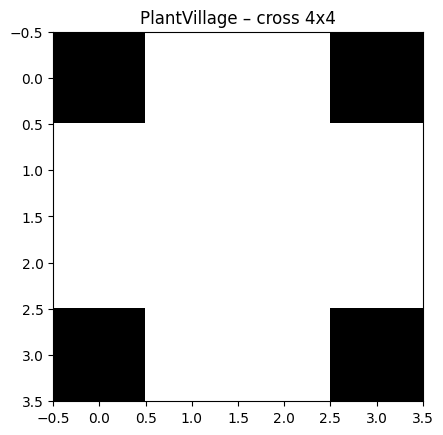

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 191s 490ms/step - accuracy: 0.4776 - loss: 2.4716 - val_accuracy: 0.0435 - val_loss: 10.5998
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 178s 461ms/step - accuracy: 0.6809 - loss: 1.1193 - val_accuracy: 0.6386 - val_loss: 1.1805
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 185s 480ms/step - accuracy: 0.7452 - loss: 0.8473 - val_accuracy: 0.5960 - val_loss: 1.4788
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 186s 482ms/step - accuracy: 0.7814 - loss: 0.7142 - val_accuracy: 0.7048 - val_loss: 0.9340
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 184s 477ms/step - accuracy: 0.8056 - loss: 0.6286 - val_accuracy: 0.7674 - val_loss: 0.7342
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 188s 487ms/step - accuracy: 0.8256 - loss: 0.5660 - val_accuracy: 0.7297 - val_loss: 0.9322
Epoch 7/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 181s 470ms/step - accuracy: 0.8372 - loss: 0.5228 - val_accuracy: 0.6735 - val_loss: 1.1106
Epoch 8/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 181s 470ms/step - accuracy: 0.8482 

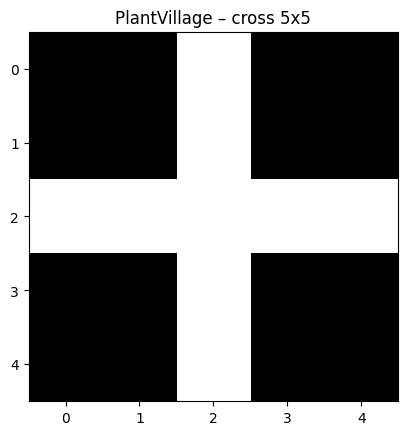

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 203s 524ms/step - accuracy: 0.4827 - loss: 2.4184 - val_accuracy: 0.0651 - val_loss: 11.0914
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 206s 535ms/step - accuracy: 0.6776 - loss: 1.1267 - val_accuracy: 0.6250 - val_loss: 1.3128
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 205s 533ms/step - accuracy: 0.7471 - loss: 0.8438 - val_accuracy: 0.6392 - val_loss: 1.2677
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 204s 530ms/step - accuracy: 0.7854 - loss: 0.7012 - val_accuracy: 0.4950 - val_loss: 2.1599
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 205s 531ms/step - accuracy: 0.8085 - loss: 0.6151 - val_accuracy: 0.6001 - val_loss: 1.3943
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 210s 545ms/step - accuracy: 0.8349 - loss: 0.5298 - val_accuracy: 0.5304 - val_loss: 1.9170
Test accuracy: 0.6374

=== Эксперимент: checkerboard, размер 2x2 ===


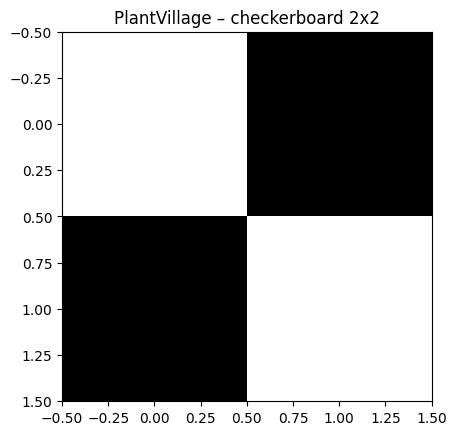

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 179s 461ms/step - accuracy: 0.4710 - loss: 2.5688 - val_accuracy: 0.0211 - val_loss: 11.4490
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 164s 426ms/step - accuracy: 0.6654 - loss: 1.1759 - val_accuracy: 0.4397 - val_loss: 2.0238
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 166s 431ms/step - accuracy: 0.7307 - loss: 0.8964 - val_accuracy: 0.1056 - val_loss: 9.2836
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 166s 432ms/step - accuracy: 0.7756 - loss: 0.7335 - val_accuracy: 0.5799 - val_loss: 1.3654
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 173s 450ms/step - accuracy: 0.8104 - loss: 0.6179 - val_accuracy: 0.7375 - val_loss: 0.8506
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 171s 443ms/step - accuracy: 0.8273 - loss: 0.5582 - val_accuracy: 0.5301 - val_loss: 1.5451
Epoch 7/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 155s 404ms/step - accuracy: 0.8403 - loss: 0.5167 - val_accuracy: 0.1254 - val_loss: 13.7188
Epoch 8/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 146s 378ms/step - accuracy: 0.8491

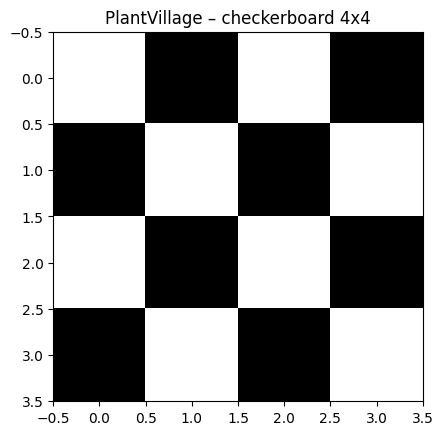

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 165s 425ms/step - accuracy: 0.4897 - loss: 2.4127 - val_accuracy: 0.0348 - val_loss: 10.9644
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 163s 423ms/step - accuracy: 0.6716 - loss: 1.1674 - val_accuracy: 0.5546 - val_loss: 1.5803
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 161s 418ms/step - accuracy: 0.7326 - loss: 0.8868 - val_accuracy: 0.7147 - val_loss: 0.8888
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 163s 425ms/step - accuracy: 0.7684 - loss: 0.7479 - val_accuracy: 0.6696 - val_loss: 1.0961
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 162s 422ms/step - accuracy: 0.7981 - loss: 0.6553 - val_accuracy: 0.5843 - val_loss: 1.3718
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 161s 419ms/step - accuracy: 0.8186 - loss: 0.5862 - val_accuracy: 0.6625 - val_loss: 1.0911
Test accuracy: 0.7175

=== Эксперимент: checkerboard, размер 6x6 ===


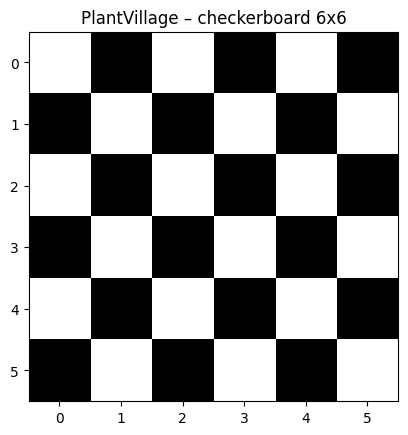

Epoch 1/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 187s 482ms/step - accuracy: 0.4719 - loss: 2.3996 - val_accuracy: 0.0992 - val_loss: 6.4639
Epoch 2/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 185s 479ms/step - accuracy: 0.6654 - loss: 1.1472 - val_accuracy: 0.6887 - val_loss: 1.0301
Epoch 3/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 184s 478ms/step - accuracy: 0.7312 - loss: 0.8835 - val_accuracy: 0.7491 - val_loss: 0.8232
Epoch 4/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 184s 477ms/step - accuracy: 0.7687 - loss: 0.7484 - val_accuracy: 0.5751 - val_loss: 1.7109
Epoch 5/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 185s 480ms/step - accuracy: 0.7947 - loss: 0.6642 - val_accuracy: 0.6525 - val_loss: 1.1623
Epoch 6/25
385/385 ━━━━━━━━━━━━━━━━━━━━ 185s 480ms/step - accuracy: 0.8115 - loss: 0.6005 - val_accuracy: 0.7335 - val_loss: 0.8697
Test accuracy: 0.7515


In [6]:
EPOCHS = 25
BATCH_SIZE = 128
IMG_SIZE = (64, 64) 
DATA_DIR = './plantvillage/Plant_leave_diseases_dataset_with_augmentation'
# ------------------- Загрузка данных через генератор -------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    validation_split=0.2      # 20% данных используем для валидации/теста
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = len(train_generator.class_indices)
print(f"Количество классов: {num_classes}")
print(f"Классы: {train_generator.class_indices}")

# ------------------- Эксперименты -------------------
experiments = {
    'full': {
        'sizes': [3, 5],
        'mask_fn': full_mask
    },
    'circle': {
        'sizes': [5, 6],
        'mask_fn': circular_mask
    },
    'cross': {
        'sizes': [2, 3, 4, 5],
        'mask_fn': cross_mask
    },
    'checkerboard': {
        'sizes': [2, 4, 6],
        'mask_fn': checkerboard_mask
    }
}

all_results = []

for exp_name, exp_data in experiments.items():
    for size in exp_data['sizes']:
        print(f"\n=== Эксперимент: {exp_name}, размер {size}x{size} ===")
        mask = exp_data['mask_fn'](size)

        # Визуализация маски (опционально)
        plt.imshow(mask, cmap='gray')
        plt.title(f'PlantVillage – {exp_name} {size}x{size}')
        plt.show()

        model = build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                            num_classes=num_classes,
                            mask=mask,
                            kernel_size=size)

        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # можно подобрать
        model.compile(optimizer=optimizer,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3, restore_best_weights=True
        )

        # Сброс генераторов для каждого эксперимента (чтобы порядок батчей был одинаков)
        # Но можно и не сбрасывать, т.к. seed фиксирован

        history = model.fit(
            train_generator,
            steps_per_epoch=None,
            validation_data=val_generator,
            validation_steps=None,
            epochs=EPOCHS,
            callbacks=[early_stop],
            verbose=1
        )

        # Оценка на валидационной выборке (используем как тест)
        test_loss, test_acc = model.evaluate(val_generator, verbose=0)
        all_results.append({
            'filter_type': exp_name,
            'size': size,
            'test_accuracy': test_acc,
            'params': model.count_params()
        })
        print(f"Test accuracy: {test_acc:.4f}")




Результаты экспериментов на PlantVillage:
     filter_type  size  test_accuracy  params
5          cross     3       0.895354  658791
6          cross     4       0.877207  673799
3         circle     6       0.802099  716679
4          cross     2       0.772724  648071
1           full     5       0.764098  693095
10  checkerboard     6       0.751485  716679
8   checkerboard     2       0.733990  648071
2         circle     5       0.732932  693095
9   checkerboard     4       0.717471  673799
0           full     3       0.706892  658791
7          cross     5       0.637399  693095


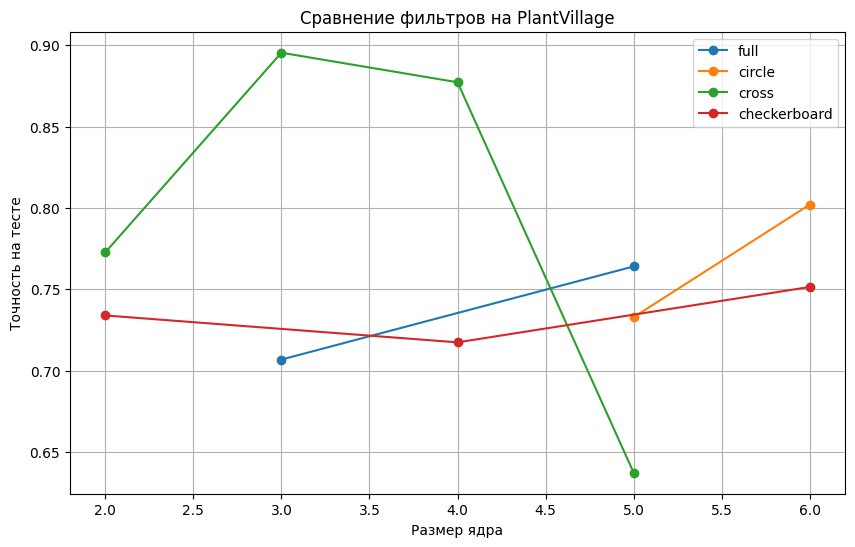


Лучший результат: cross размер 3 с точностью 0.8954


In [9]:
# ------------------- Итоговая таблица и график -------------------
df = pd.DataFrame(all_results)
print("\nРезультаты экспериментов на PlantVillage:")
print(df.sort_values('test_accuracy', ascending=False))

plt.figure(figsize=(10, 6))
for ft in df['filter_type'].unique():
    sub = df[df['filter_type'] == ft]
    plt.plot(sub['size'], sub['test_accuracy'], marker='o', label=ft)
plt.xlabel('Размер ядра')
plt.ylabel('Точность на тесте')
plt.title('Сравнение фильтров на PlantVillage')
plt.legend()
plt.grid(True)
plt.show()

# Вывод лучшего результата
best = df.loc[df['test_accuracy'].idxmax()]
print(f"\nЛучший результат: {best['filter_type']} размер {best['size']} с точностью {best['test_accuracy']:.4f}")

Отсортированные результаты:
     filter_type  size  test_accuracy  params
0   checkerboard     2       0.733990  648071
1          cross     2       0.772724  648071
2          cross     3       0.895354  658791
3           full     3       0.706892  658791
4   checkerboard     4       0.717471  673799
5          cross     4       0.877207  673799
6         circle     5       0.732932  693095
7          cross     5       0.637399  693095
8           full     5       0.764098  693095
9   checkerboard     6       0.751485  716679
10        circle     6       0.802099  716679


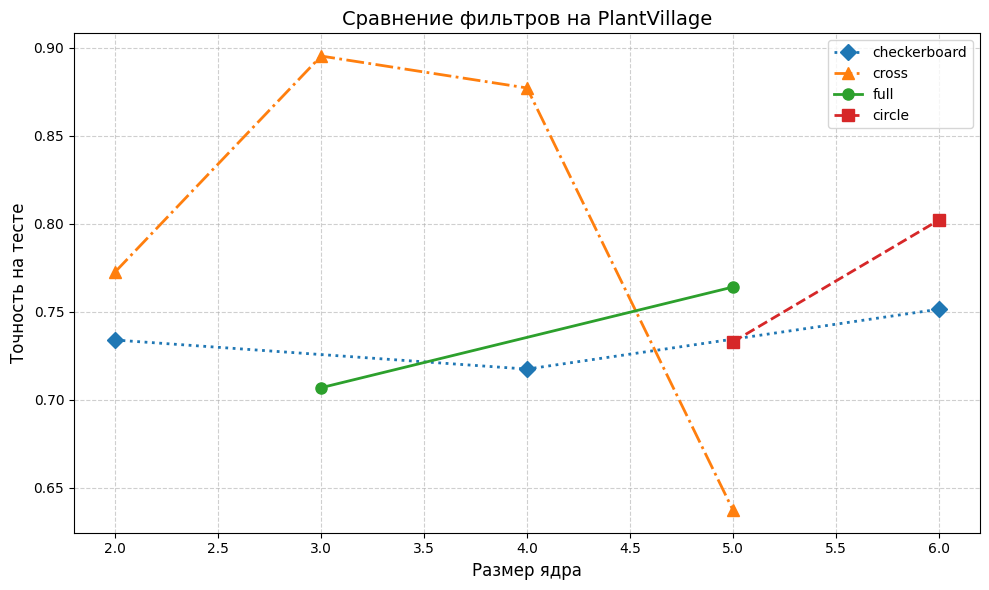

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Данные
data = {
    'filter_type': ['cross', 'cross', 'circle', 'cross', 'full', 
                    'checkerboard', 'checkerboard', 'circle', 'checkerboard', 'full', 'cross'],
    'size': [3, 4, 6, 2, 5, 6, 2, 5, 4, 3, 5],
    'test_accuracy': [0.895354, 0.877207, 0.802099, 0.772724, 0.764098,
                      0.751485, 0.733990, 0.732932, 0.717471, 0.706892, 0.637399],
    'params': [658791, 673799, 716679, 648071, 693095,
               716679, 648071, 693095, 673799, 658791, 693095]
}

df = pd.DataFrame(data)

# Сортируем по размеру, затем по типу (чтобы было упорядочено)
df = df.sort_values(['size', 'filter_type']).reset_index(drop=True)

print("Отсортированные результаты:")
print(df)

# Построение графика
linestyles = {
    'full': '-',
    'circle': '--',
    'cross': '-.',
    'checkerboard': ':'
}
markers = {
    'full': 'o',
    'circle': 's',
    'cross': '^',
    'checkerboard': 'D'
}

plt.figure(figsize=(10, 6))
for ft in df['filter_type'].unique():
    sub = df[df['filter_type'] == ft]
    plt.plot(sub['size'], sub['test_accuracy'],
             marker=markers.get(ft, 'o'),
             linestyle=linestyles.get(ft, '-'),
             label=ft,
             linewidth=2,
             markersize=8)

plt.xlabel('Размер ядра', fontsize=12)
plt.ylabel('Точность на тесте', fontsize=12)
plt.title('Сравнение фильтров на PlantVillage', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()